## Exploratory Data Analysis and Feature Engineering
### Churn Prediction
*This section of the project we shall be performing some EDA, to get a better understanding of the data. We shall also perform feature engineering, in order to remove unusual & duplicate values*


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [15]:
df.head

<bound method NDFrame.head of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL   

In [28]:
df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()][['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


In [30]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

In [31]:
df['TotalCharges'].dtype


dtype('float64')

In [32]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [33]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [34]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [35]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [36]:
df = df.drop('customerID', axis=1)

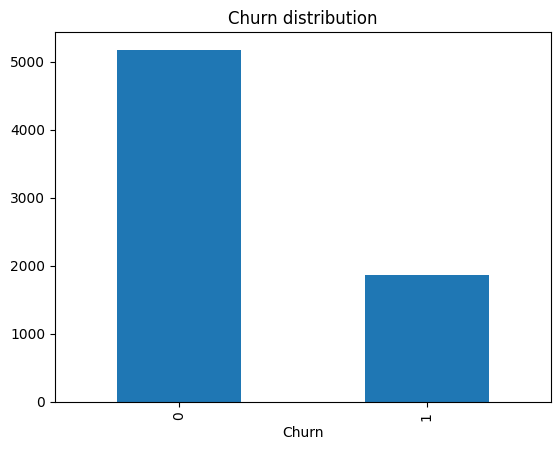

In [38]:
# Churn Distribution
df['Churn'].value_counts().plot(kind='bar')
plt.title('Churn distribution')
plt.show()

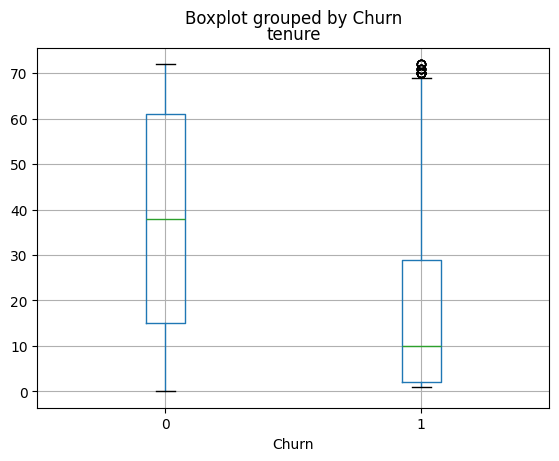

In [39]:
# Tenure vs Churn 
df.boxplot(column='tenure', by='Churn')
plt.show()

**Insight:** Churned customers have significantly lower tenure (median ~10 months) 
compared to retained customers (median ~38 months). New customers are at much 
higher risk of churning.

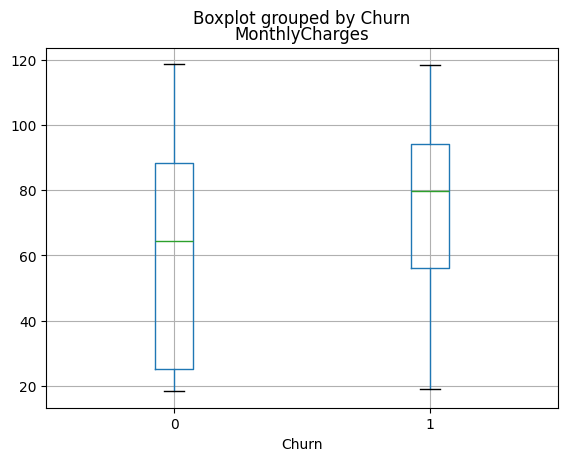

In [40]:
# Monthly Charges vs Churn

df.boxplot(column='MonthlyCharges', by='Churn')
plt.show()

## Insight: Monthly Charges vs Churn

Customers who churned tend to have higher monthly charges (median ~$79) 
compared to customers who stayed (median ~$64). This suggests that customers 
on more expensive plans are at higher risk of churning, possibly due to 
perceived lack of value for money.

Combined with the tenure analysis, the at-risk customer profile emerging is:
**new customers on high monthly charges.**

In [41]:
# Feature Engineering
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = df.select_dtypes(include='object').columns.tolist()